Load the csv file to a dataframe in python

In [1]:
# Import the required python libraries 
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Read the original data to the pandas dataaframe 
source_data = pd.read_csv("/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/train-balanced-sarcasm.csv")


In [3]:
source_data

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...
...,...,...,...,...,...,...,...,...,...,...
1010821,1,I'm sure that Iran and N. Korea have the techn...,TwarkMain,reddit.com,2,2,0,2009-04,2009-04-25 00:47:52,"No one is calling this an engineered pathogen,..."
1010822,1,"whatever you do, don't vote green!",BCHarvey,climate,1,1,0,2009-05,2009-05-14 22:27:40,In a move typical of their recent do-nothing a...
1010823,1,Perhaps this is an atheist conspiracy to make ...,rebelcommander,atheism,1,1,0,2009-01,2009-01-11 00:22:57,Screw the Disabled--I've got to get to Church ...
1010824,1,The Slavs got their own country - it is called...,catsi,worldnews,1,1,0,2009-01,2009-01-23 21:12:49,I've always been unsettled by that. I hear a l...


## **Understanding the columns of the dataset**

1. label : The label given to the comment in which 0
indicate the comment is non sarcastic and 1 indicates the comment is sarcastic
2. comment : The response comment given to the paret comment
3. author: user name for the author of the comment
4. subreddit : the specific topic discussed in the comment
5. score : A score calculated for the comment by considering the ups and downs scores for the net popularity score(ups-downs)
6. ups: the number of upvotes which indicate people who actually found the comment funny or insightful
7. downs:number of downvotes indicating people who found the comment offended or not as a joke
8. date: the date in which the comment was posted on reddit
created_utc: The utc timestamp idicating when the comment was posted.
9. parent_comment : the parent comment made by the user, which prompted the sarcastic response

In [4]:
# Data info
source_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


In [5]:
# drop the columns that are not required ["author","date","created_utc"]

columns_not_needed = ["author", "date", "created_utc"]
source_data = source_data.drop(columns=columns_not_needed)

# print the remining columns of the source_data
print(source_data.columns)

Index(['label', 'comment', 'subreddit', 'score', 'ups', 'downs',
       'parent_comment'],
      dtype='object')


# **Extracting Finance data from the source data**

By focusing on the coulmn "subredit" we can identify the comment belongs to which area.From this extract the rows which has finance related subreddit values

In [6]:
# get the unique values inside the subreddit column

unique_subreddits = source_data["subreddit"].unique()
print(unique_subreddits)

['politics' 'nba' 'nfl' ... 'PigJargon' 'Learnmusic' 'Pandemic']


In [7]:
print(len(unique_subreddits))

14878


In [8]:
# since the count of uniques values are high it can be saved into a csv file with counts before selecting the required financial data


# Get the  count of each subreddit
count_of_subreddits = source_data["subreddit"].value_counts().reset_index()

# Name the columns of the new dataframe
count_of_subreddits.columns = ["subreddit", "count"]

# Path to save the subreddit_counts.csv

save_subreddit_counts_to = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/subreddit_counts.csv"

# Save to a CSV file without including the row index integers
count_of_subreddits.to_csv(save_subreddit_counts_to, index=False)

print("Subreddit  count data successfully saved to 'subreddit_counts.csv'")

Subreddit  count data successfully saved to 'subreddit_counts.csv'


From the subreddit_counts.csv it is understood that the count of unique values ranges from 1 to 65677. To make the process simple delete the aubreddit names for which the count is less than 100

In [9]:
# path to the subreddit count csv file
subreddit_counts_path = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/subreddit_counts.csv"

# path to the filterd output which have unique value count greater than 100

filtered_outputs_1 = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/subreddit_counts_filtered_1.csv"

# Load the existing subreddit_counts CSV file
subreddit_counts = pd.read_csv(subreddit_counts_path)

# remove the  rows where the count is less than 100
subreddit_counts_filtered = subreddit_counts[subreddit_counts['count'] >= 100]

# rewrite and update the original file
subreddit_counts_filtered.to_csv(filtered_outputs_1, index=False)

# print the results
print("Length of Original dataset : ", len(subreddit_counts))
print("Updated count of  unique subreddits after filtering : ", len(subreddit_counts_filtered))


Length of Original dataset :  14878
Updated count of  unique subreddits after filtering :  978


from the dataset subreddit_counts.csv the selected subreddit names are     
1. “Bitcoin”
2. ”paydaytheheist”
3. ”TalesFromRetail”,
4. ”personalfinance”
5. ”investing”
6. ”business”
7. ”BitcoinMarkets”
8. ”Accounting”
9. ”financialindependence”
10. ”Buttcoin”
11. ”BasicIncome”

some of these names do not find very accurate hense one more search will be doe to filter out the naes which has count less than 100 and greater than 50 .

From this the names that looks relevant are
1. “stocks”
2. ”PersonalFinanceCanada”
3. ”finance”

In [10]:
# Path to the  subreddit count csv file
subreddit_counts_path = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/subreddit_counts.csv"

# CHANGED: Create a specific path for this new filtered range file
filtered_outputs_2 = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/subreddit_counts_filtered_2.csv"

# Load the existing subreddit_counts CSV file
subreddit_counts = pd.read_csv(subreddit_counts_path)

# remove rows except the count is  less than 100 AND greater than 10
subreddit_counts_filtered = subreddit_counts[(subreddit_counts['count'] < 100) & (subreddit_counts['count'] > 50)]

# save the data into a new csv file
subreddit_counts_filtered.to_csv(filtered_outputs_2, index=False)

# Print the results
print("Length of Original dataset : ", len(subreddit_counts))
print("Count of unique subreddits between 10 and 100 : ", len(subreddit_counts_filtered))


Length of Original dataset :  14878
Count of unique subreddits between 10 and 100 :  513


# Creating the final dataset named financial_sarcasm_dataset.csv

The final subreddit names selecetd for creating the financial data are

1. “Bitcoin”
2. ”investing”
3. ”Accounting”
4. “stocks”
5. ”finance”


By filtering the data that contrains these subreddit values a new dataset will be created and it can be names as financial_data


In [11]:
# path to save the financial data
financial_data_path = "/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/financial_sarcasm_dataset.csv"

# The  list containing the  target financial subreddits
selecetd_subreddits = ["Bitcoin", "investing", "Accounting", "stocks", "finance"]

# Filter the source data by filtering the subreddit names that nateches with one of the 5 values inside the selected subreddits list by using .isin()
financial_data = source_data[source_data["subreddit"].isin(selecetd_subreddits)]


# Save the filtered financial data to a new CSV file
financial_data.to_csv(financial_data_path, index=False)

# Print the results to verify everything worked perfectly
print("Length of original  dataset: ", len(source_data))
print("Length of  financial dataset: ", len(financial_data))
print("Financial dataset successfully saved to", financial_data_path)



Length of original  dataset:  1010826
Length of  financial dataset:  2942
Financial dataset successfully saved to /Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/financial_sarcasm_dataset.csv


# **Data Visualization**

label          0     1
subreddit             
Accounting    78    60
Bitcoin     1076  1275
finance       25    33
investing    143   186
stocks        34    32
Axes(0.125,0.11;0.775x0.77)


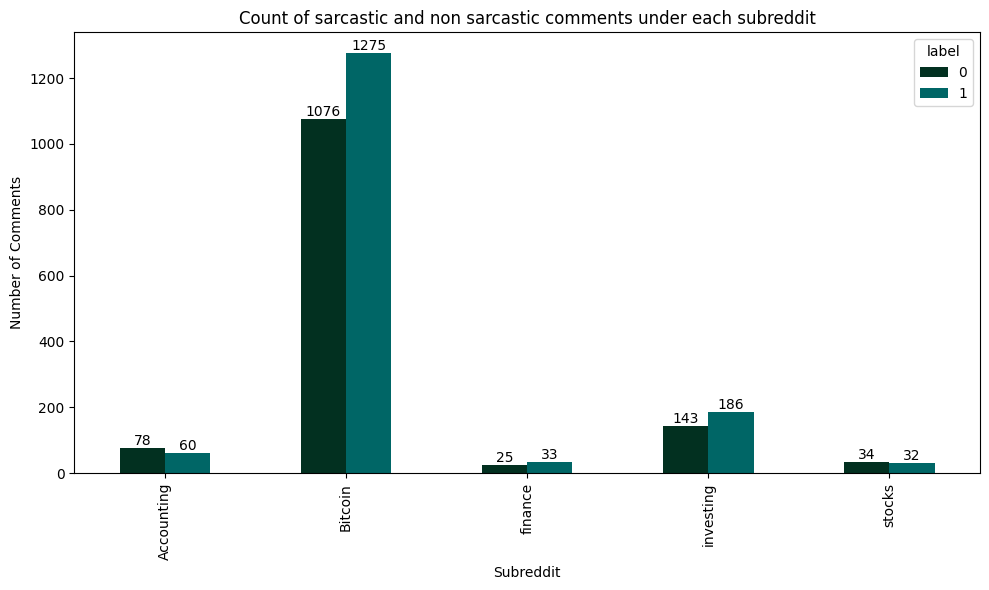

In [12]:
# count the number of sarcastic and non sarcastic comments for each subreddit.
label_counts = pd.crosstab(financial_data["subreddit"], financial_data["label"])
print(label_counts)

# Create bargraph using the label count  and assign it to bars
bar_graph = label_counts.plot(kind="bar", color=["#023020", "#006666"], figsize=(10, 6))
print(bar_graph)


# To add the comments on top of each bar iterate through each bar and add the text label automatically
for container in bar_graph.containers:
    bar_graph.bar_label(container)

# Add  labels and a title
plt.title("Count of sarcastic and non sarcastic comments under each subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Number of Comments")

# display the graph
plt.tight_layout()
plt.show()

In [13]:
# File path to save the new dataset
file_path = '/Users/jisha/Desktop/Sarcasm_Final/Exploratory_Data_Analysis/financial_sarcasm_dataset.csv'


# Calculate the comment length of the comments in the commet column
comments_length = financial_data['comment'].astype(str).str.len()

# Filter the data by selecting comments that have length between 10 and 100. These values are selected after analysing density graph
filtered_data = financial_data[(comments_length >= 10) & (comments_length <= 100)]

# Overwrite the existing CSV file and erase the evidence of the old rows
filtered_data.to_csv(file_path, index=False)

print(f"The dataset is trimed from {len(financial_data)}  to {len(filtered_data)} rows.")

The dataset is trimed from 2942  to 2423 rows.


In [14]:
filtered_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2423 entries, 1474 to 1010597
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   label           2423 non-null   int64 
 1   comment         2423 non-null   object
 2   subreddit       2423 non-null   object
 3   score           2423 non-null   int64 
 4   ups             2423 non-null   int64 
 5   downs           2423 non-null   int64 
 6   parent_comment  2423 non-null   object
dtypes: int64(4), object(3)
memory usage: 151.4+ KB


In [15]:
# The size of the dataset still looks large,Hence trying to reduce the size by balacing the number of sarcastic and non sarcastic comments under each subreddit
# Function balance the data by considering 50% sarcastic and 50% non sarcastic comments under each subreddit
def balance_subreddit(group):
    sarcastic = group[group['label'] == 1]
    non_sarcastic = group[group['label'] == 0]
    
    # Find the number of sarcastic and non sarcastic comments under a subreddit and choose the minimum number among sarcastic and non sarcastic
    minimum_size = min(len(sarcastic), len(non_sarcastic))
    
    # Considerin the miningm size ransomly selecet the sarcastic and non sarcastic comments under a subreddit
    sarcastic_sample = sarcastic.sample(n=minimum_size, random_state=42)
    non_sarcastic_sample = non_sarcastic.sample(n=minimum_size, random_state=42)
    
    return pd.concat([sarcastic_sample, non_sarcastic_sample])

# Go through each subreddit and balance the data under each subreddit
filtered_data = filtered_data.groupby('subreddit', group_keys=False).apply(balance_subreddit)

# Shuffle the final
filtered_data = filtered_data.sample(frac=1, random_state=42).reset_index(drop=True)

# print the count of saracstic and non sarcastic comments under each subbreddit after balancing the data and the final size of the data 
print(filtered_data.groupby(['subreddit', 'label']).size())
print(f" Total number of rows in the final dataset: {len(filtered_data)}")

subreddit   label
Accounting  0         50
            1         50
Bitcoin     0        854
            1        854
finance     0         18
            1         18
investing   0        108
            1        108
stocks      0         27
            1         27
dtype: int64
 Total number of rows in the final dataset: 2114


/var/folders/_4/2gdtmzcn7z1fft_07lp0z53c0000gn/T/ipykernel_1592/1669952976.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_data = filtered_data.groupby('subreddit', group_keys=False).apply(balance_subreddit)


In [16]:
# From the above result it is clear that the number of comments on bitcoin is very high compared to the other subreddits. Hence the data is trimed again to reduce the data size so that the model processing time will be less

# The maximum entries under each subreddit is fixed into 100


# Create a function to trim the data into 100 entries maximum
def strict_balance(group):
    sarcastic = group[group['label'] == 1]
    non_sarcastic = group[group['label'] == 0]
    sample_size = min(len(sarcastic), len(non_sarcastic), 100)
    sarcastic_sample = sarcastic.sample(n=sample_size, random_state=42)
    non_sarcastic_sample = non_sarcastic.sample(n=sample_size, random_state=42)
    
    return pd.concat([sarcastic_sample, non_sarcastic_sample])


# Apply the  function and reduce the data size
tiny_balanced_df = filtered_data.groupby('subreddit', group_keys=False).apply(strict_balance)

# Shuffle the rows
tiny_balanced_df = tiny_balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)


print(tiny_balanced_df.groupby(['subreddit', 'label']).size())
print(f"\nTotal number  of rows in the new tiny dataset: {len(tiny_balanced_df)}")




subreddit   label
Accounting  0         50
            1         50
Bitcoin     0        100
            1        100
finance     0         18
            1         18
investing   0        100
            1        100
stocks      0         27
            1         27
dtype: int64

Total number  of rows in the new tiny dataset: 590


/var/folders/_4/2gdtmzcn7z1fft_07lp0z53c0000gn/T/ipykernel_1592/809337286.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tiny_balanced_df = filtered_data.groupby('subreddit', group_keys=False).apply(strict_balance)


In [17]:
# Save this small file
tiny_balanced_df.to_csv('tiny_balanced_sarcasm.csv', index=False)

label         0    1
subreddit           
Accounting   50   50
Bitcoin     100  100
finance      18   18
investing   100  100
stocks       27   27
Axes(0.125,0.11;0.775x0.77)


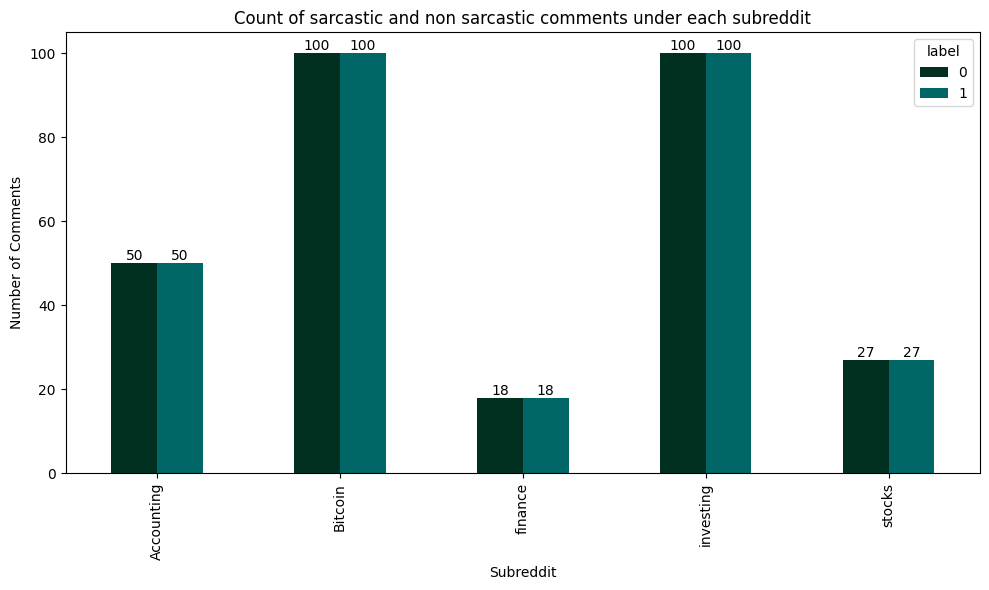

In [18]:
# count the number of sarcastic and non sarcastic comments for each subreddit.
label_counts = pd.crosstab(tiny_balanced_df["subreddit"], tiny_balanced_df["label"])
print(label_counts)

# Create bargraph using the label count  and assign it to bars
bar_graph = label_counts.plot(kind="bar", color=["#023020", "#006666"], figsize=(10, 6))
print(bar_graph)


# To add the comments on top of each bar iterate through each bar and add the text label automatically
for container in bar_graph.containers:
    bar_graph.bar_label(container)

# Add  labels and a title
plt.title("Count of sarcastic and non sarcastic comments under each subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Number of Comments")

# display the graph
plt.tight_layout()
plt.show()